<a href="https://colab.research.google.com/github/mabdulatalhakh213-ux/Northstar/blob/main/Northstar_PY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NorthStar Urban Mobility and Logistics
## Section 2 — Python Analysis
### Data Import, Cleaning, Statistical Analysis, and Visualisation

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid", palette="muted")

print("Libraries loaded successfully")
print("Analysis started at:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Libraries loaded successfully
Analysis started at: 2026-05-15 17:28:31


In [33]:
base_url = "https://raw.githubusercontent.com/mabdulatalhakh213-ux/Northstar/main/"


customers = pd.read_csv(base_url + "customers.csv")
app_events = pd.read_csv(base_url + "app_events.csv")
complaints = pd.read_csv(base_url + "complaints.csv")
deliveries = pd.read_csv(base_url + "deliveries.csv")
drivers = pd.read_csv(base_url + "drivers.csv")
hubs = pd.read_csv(base_url + "hubs.csv")
incidents = pd.read_csv(base_url + "incidents.csv")
orders = pd.read_csv(base_url + "orders.csv")
vehicles = pd.read_csv(base_url + "vehicles.csv")

In [34]:
zone_map = {
    "north":"North","south":"South","east":"East","west":"West",
    "central":"Central","ctr":"Central","airport":"Airport","riverside":"Riverside"
}

def norm_zone(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    return zone_map.get(s, s.title())

In [35]:
print("customers:", customers.shape)
print("orders:", orders.shape)
print("deliveries:", deliveries.shape)
print("drivers:", drivers.shape)
print("vehicles:", vehicles.shape)
print("hubs:", hubs.shape)
print("complaints:", complaints.shape)
print("incidents:", incidents.shape)
print("app_events:", app_events.shape)

display(customers.head())
display(orders.head())
display(deliveries.head())

customers: (650, 9)
orders: (1250, 11)
deliveries: (950, 13)
drivers: (170, 8)
vehicles: (120, 8)
hubs: (8, 5)
complaints: (320, 10)
incidents: (280, 7)
app_events: (640, 10)


,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


In [36]:
dfs = {
    "customers": customers,
    "orders": orders,
    "deliveries": deliveries,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "complaints": complaints,
    "incidents": incidents,
    "app_events": app_events
}

for name, df in dfs.items():
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)

print("Column names standardized")

Column names standardized


In [37]:
for name, df in dfs.items():
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype(str).str.strip()
        df.loc[df[col].isin(["nan", "NaN", "None", "null", "NULL", ""]), col] = np.nan

print("Text values cleaned and null markers normalized")

Text values cleaned and null markers normalized


In [38]:
date_cols = {
    "customers": ["signup_date"],
    "orders": ["order_created_at"],
    "deliveries": ["dispatch_time", "delivery_completed_at"],
    "complaints": ["created_at", "resolved_at"],
    "incidents": ["reported_at", "resolved_at"],
    "app_events": ["event_timestamp"],
    "vehicles": ["commission_date"]
}

for name, cols in date_cols.items():
    for col in cols:
        if col in dfs[name].columns:
            dfs[name][col] = pd.to_datetime(dfs[name][col], errors="coerce")

print("Date columns parsed")

Date columns parsed


In [39]:
missing_summary = {}
for name, df in dfs.items():
    missing_summary[name] = df.isna().sum().sum()

missing_summary = pd.Series(missing_summary).sort_values(ascending=False)
display(missing_summary)

,0
app_events,144
customers,33
deliveries,33
orders,25
incidents,17
complaints,16
drivers,7
vehicles,4
hubs,0


In [40]:
full = orders.merge(deliveries, on="order_id", how="left", suffixes=("", "_del"))
full = full.merge(drivers, on="driver_id", how="left")
full = full.merge(vehicles, on="vehicle_id", how="left")
full = full.merge(hubs, on="hub_id", how="left")

print("Merged dataframe shape:", full.shape)
display(full.head())

Merged dataframe shape: (1250, 41)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag,delivery_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version,hub_name,zone,hub_type,capacity_score
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0,DL00937,D047,V090,H01,2024-08-20 16:29:00,2024-08-20 18:52:56.172161,OnTime,26.65,2.0,0.0,4.29,15.82,South,FullTime,7.0,64.6,4.70,Morning,1.0,Hybrid,WEST,2024-08-16 01:10:00,93.8,98472.0,InRepair,v2.0,North Exchange,North,Dispatch,82.0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0,DL00925,D041,V100,H02,2025-09-02 16:59:00,2025-09-03 01:50:39.644673,Delayed,13.04,2.0,0.0,3.70,13.16,EAST,PartTime,3.0,88.2,3.67,Morning,1.0,CargoVan,East,2024-06-23 11:24:00,60.1,31876.0,Active,v2.0,South Link,South,Dispatch,78.0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1,DL00002,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1.0,0.0,5.00,13.41,Ctr,PartTime,11.0,69.2,4.61,Evening,1.0,Diesel,AIRPORT,2025-09-17 08:52:00,68.6,78468.0,Active,v2.2,South Link,South,Dispatch,78.0
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0,DL00671,D054,V073,H03,2025-02-17 20:23:00,2025-02-18 08:05:00.047082,OnTime,16.01,1.0,0.0,4.38,13.53,WEST,FullTime,3.0,80.1,4.32,Morning,1.0,Hybrid,AIRPORT,2024-05-28 05:33:00,NaN,191353.0,Active,v2.1,East Dock,East,Warehouse,74.0


In [41]:
for c in ["pickup_zone", "dropoff_zone", "base_zone", "assigned_zone", "zone", "home_zone"]:
    if c in full.columns:
        full[c] = full[c].astype(str).str.strip().str.title()

display(full[[c for c in ["pickup_zone", "dropoff_zone", "base_zone", "assigned_zone"] if c in full.columns]].head())

,pickup_zone,dropoff_zone,base_zone,assigned_zone
0,Airport,South,South,West
1,North,Airport,Nan,Nan
2,West,Airport,East,East
3,Riverside,North,Ctr,Airport
4,Riverside,South,West,Airport


In [42]:
numeric_cols = [
    "promised_window_hours",
    "manual_route_override_count",
    "customer_rating_post_delivery",
    "fuel_or_charge_cost",
    "order_value",
    "route_distance_km",
    "battery_health_pct",
    "training_score",
    "driver_rating",
    "years_experience",
    "capacity_score",
    "resolution_days",
    "compensation_amount",
    "api_latency_ms"
]

for col in numeric_cols:
    if col in full.columns:
        full[col] = pd.to_numeric(full[col], errors="coerce")

print("Numeric columns converted")

Numeric columns converted


In [43]:
full["delivery_duration_hours"] = (full["delivery_completed_at"] - full["dispatch_time"]).dt.total_seconds() / 3600
full.loc[full["delivery_duration_hours"] < 0, "delivery_duration_hours"] = np.nan

full["delay_hours"] = full["delivery_duration_hours"] - full["promised_window_hours"]
full["is_late"] = (full["delay_hours"] > 0).astype(int)

display(full[["order_id", "delivery_duration_hours", "promised_window_hours", "delay_hours", "is_late"]].head(10))

,order_id,delivery_duration_hours,promised_window_hours,delay_hours,is_late
0,O00001,2.398937,6,-3.601063,0
1,O00002,NaN,24,NaN,0
2,O00003,8.861012,4,4.861012,1
3,O00004,NaN,2,NaN,0
4,O00005,11.700013,12,-0.299987,0
5,O00006,NaN,1,NaN,0
6,O00007,8.921543,2,6.921543,1
7,O00008,0.415726,4,-3.584274,0
8,O00009,9.748426,12,-2.251574,0
9,O00010,2.996207,6,-3.003793,0


In [44]:
full["is_failed"] = full["delivery_status"].astype(str).str.lower().isin(
    ["failed", "cancelled", "exception", "returned"]
).astype(int)

if "manual_route_override_count" in full.columns:
    full["is_override"] = (full["manual_route_override_count"].fillna(0) > 0).astype(int)
else:
    full["is_override"] = 0

if "proof_of_completion_missing" in full.columns:
    full["proof_missing"] = full["proof_of_completion_missing"].astype(str).str.lower().isin(
        ["1", "true", "yes", "t", "y"]
    ).astype(int)
else:
    full["proof_missing"] = 0

full["service_quality_issue"] = (
    (full["is_late"] == 1) |
    (full["is_failed"] == 1) |
    (full["is_override"] == 1)
).astype(int)

display(full[["order_id", "delivery_status", "is_late", "is_failed", "is_override", "service_quality_issue"]].head(10))

,order_id,delivery_status,is_late,is_failed,is_override,service_quality_issue
0,O00001,OnTime,0,0,1,1
1,O00002,NaN,0,0,0,0
2,O00003,Delayed,1,0,1,1
3,O00004,OnTime,0,0,1,1
4,O00005,OnTime,0,0,1,1
5,O00006,NaN,0,0,0,0
6,O00007,Delayed,1,0,1,1
7,O00008,OnTime,0,0,0,0
8,O00009,OnTime,0,0,0,0
9,O00010,OnTime,0,0,1,1


In [45]:
if "customer_rating_post_delivery" in full.columns and "delivery_status" in full.columns:
    full["customer_rating_post_delivery"] = full.groupby("delivery_status")["customer_rating_post_delivery"].transform(
        lambda x: x.fillna(x.median())
    )

print("Missing ratings imputed where possible")
display(full[["delivery_status", "customer_rating_post_delivery"]].head(10))

Missing ratings imputed where possible


,delivery_status,customer_rating_post_delivery
0,OnTime,4.29
1,NaN,NaN
2,Delayed,3.70
3,OnTime,5.00
4,OnTime,4.38
5,NaN,NaN
6,Delayed,3.93
7,OnTime,5.00
8,OnTime,4.45
9,OnTime,4.23


In [46]:
stats_cols = [
    "order_value",
    "route_distance_km",
    "fuel_or_charge_cost",
    "customer_rating_post_delivery",
    "delivery_duration_hours",
    "delay_hours",
    "training_score",
    "battery_health_pct"
]

available_stats = [c for c in stats_cols if c in full.columns]
desc = full[available_stats].describe().T
display(desc)

,count,mean,std,min,25%,50%,75%,max
order_value,1250.0,91.050520,60.917783,2.040000,47.915000,76.530000,121.097500,510.060000
route_distance_km,950.0,13.909316,7.477907,1.200000,9.135000,12.840000,16.835000,41.940000
fuel_or_charge_cost,950.0,12.841295,4.336468,2.500000,9.925000,12.645000,15.697500,29.430000
customer_rating_post_delivery,950.0,3.864179,0.890524,1.000000,3.350000,4.040000,4.550000,5.000000
delivery_duration_hours,867.0,10.317151,8.463124,0.022565,3.501689,7.913109,15.528078,43.456918
delay_hours,867.0,2.326378,5.586342,-5.235659,-1.668207,0.017387,5.399595,19.722666
training_score,910.0,74.617253,11.530829,40.600000,68.175000,74.300000,83.000000,99.000000
battery_health_pct,925.0,76.968865,12.391979,42.000000,68.300000,78.100000,86.600000,100.000000


In [47]:
summary = pd.DataFrame({
    "metric": [
        "late_rate",
        "failed_rate",
        "override_rate",
        "service_quality_issue_rate",
        "average_delay_hours",
        "average_order_value"
    ],
    "value": [
        full["is_late"].mean(),
        full["is_failed"].mean(),
        full["is_override"].mean(),
        full["service_quality_issue"].mean(),
        full["delay_hours"].mean(),
        full["order_value"].mean()
    ]
})

display(summary)

,metric,value
0,late_rate,0.348000
1,failed_rate,0.105600
2,override_rate,0.440800
3,service_quality_issue_rate,0.581600
4,average_delay_hours,2.326378
5,average_order_value,91.050520


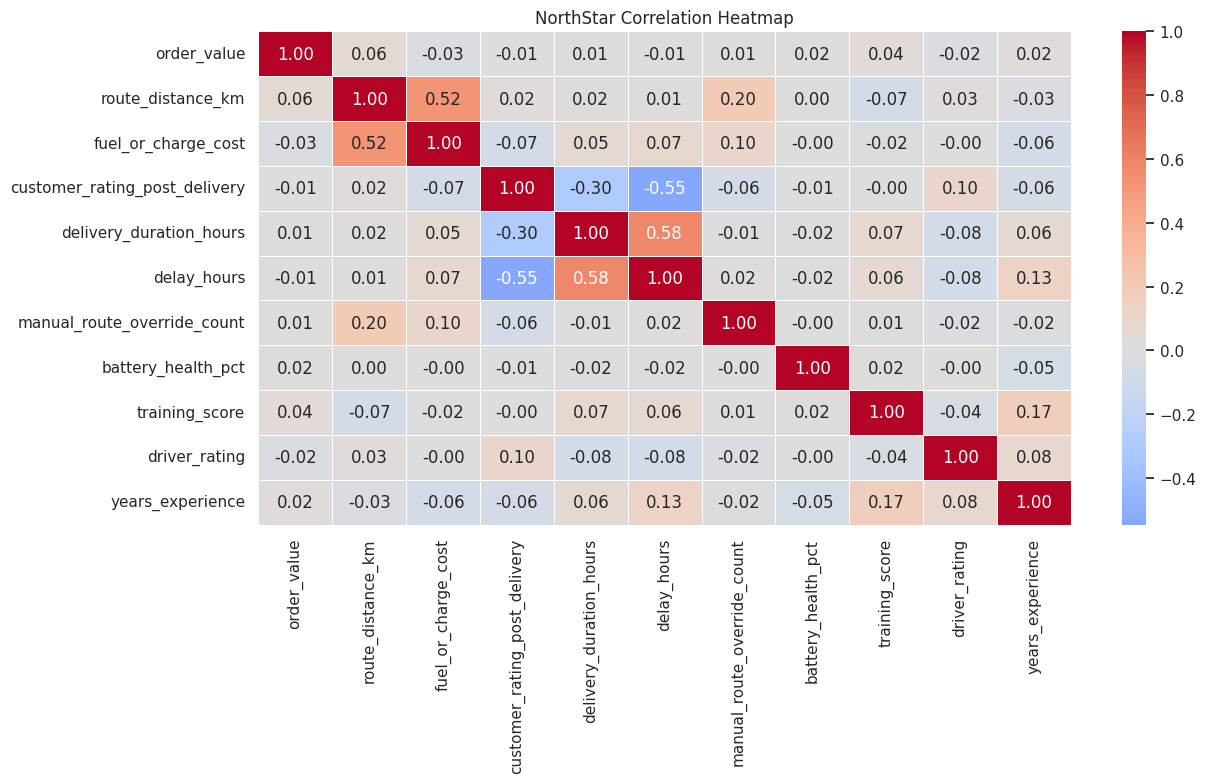

In [48]:
corr_cols = [c for c in [
    "order_value",
    "route_distance_km",
    "fuel_or_charge_cost",
    "customer_rating_post_delivery",
    "delivery_duration_hours",
    "delay_hours",
    "manual_route_override_count",
    "battery_health_pct",
    "training_score",
    "driver_rating",
    "years_experience"
] if c in full.columns]

corr = full[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(13, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
plt.title("NorthStar Correlation Heatmap")
plt.tight_layout()
plt.savefig("northstar_correlation_heatmap.png", dpi=300)
plt.show()

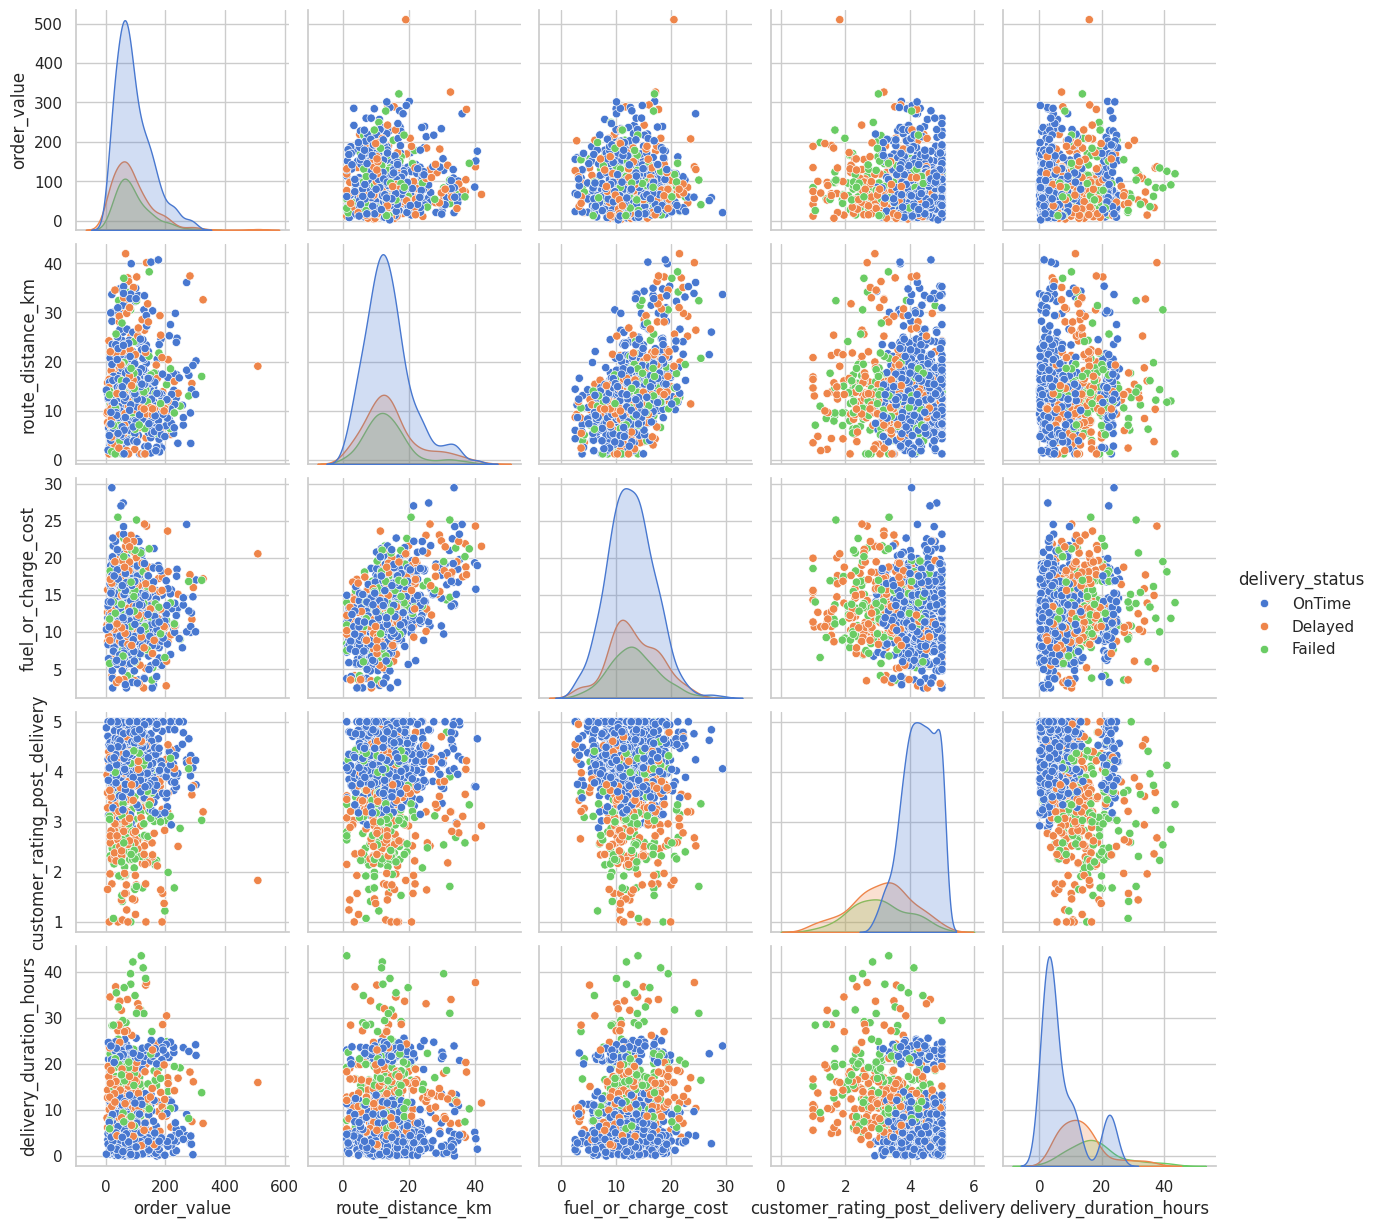

In [49]:
pair_cols = [c for c in [
    "order_value",
    "route_distance_km",
    "fuel_or_charge_cost",
    "customer_rating_post_delivery",
    "delivery_duration_hours"
] if c in full.columns]

pair_df = full[pair_cols + (["delivery_status"] if "delivery_status" in full.columns else [])].dropna()

sns.pairplot(pair_df, hue="delivery_status" if "delivery_status" in pair_df.columns else None)
plt.savefig("northstar_pairplot.png", dpi=300)
plt.show()

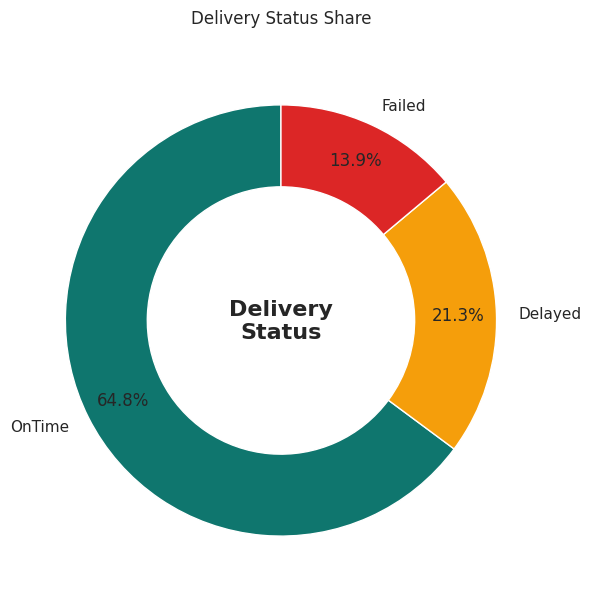

In [50]:
status_counts = deliveries["delivery_status"].value_counts()

fig, ax = plt.subplots(figsize=(7,7))
colors = ["#0f766e", "#f59e0b", "#dc2626", "#94a3b8"]

ax.pie(
    status_counts.values,
    labels=status_counts.index,
    colors=colors[:len(status_counts)],
    startangle=90,
    wedgeprops=dict(width=0.38, edgecolor="white"),
    autopct="%1.1f%%",
    pctdistance=0.82
)
ax.text(0, 0, "Delivery\nStatus", ha="center", va="center", fontsize=16, fontweight="bold")
ax.set_title("Delivery Status Share", pad=20)
plt.show()

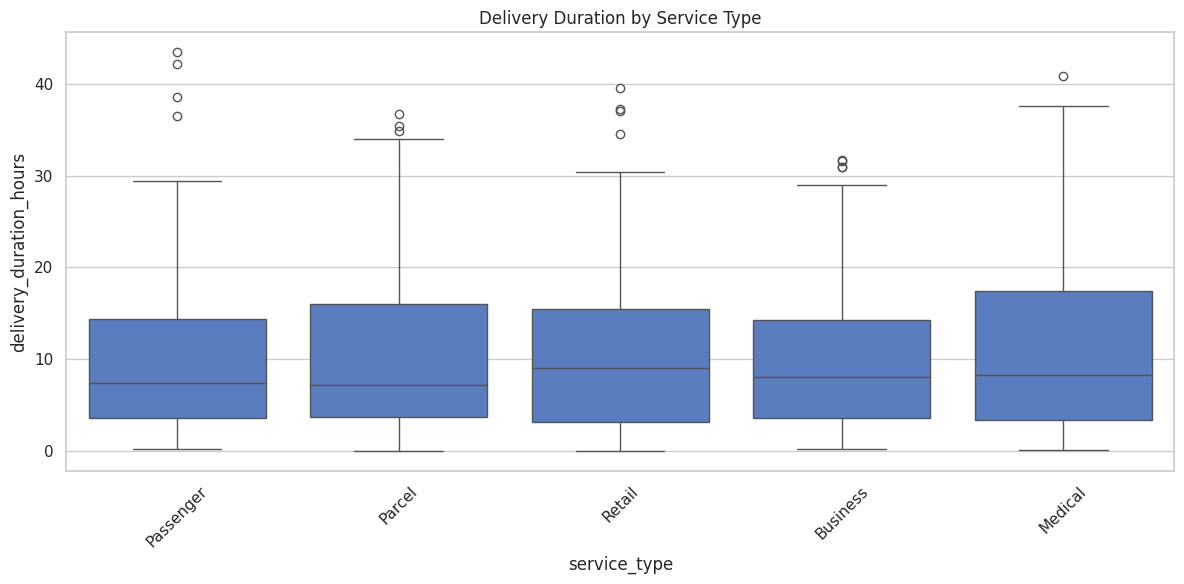

In [51]:
if "service_type" in full.columns and "delivery_duration_hours" in full.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=full, x="service_type", y="delivery_duration_hours")
    plt.title("Delivery Duration by Service Type")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("northstar_boxplot_service_type.png", dpi=300)
    plt.show()

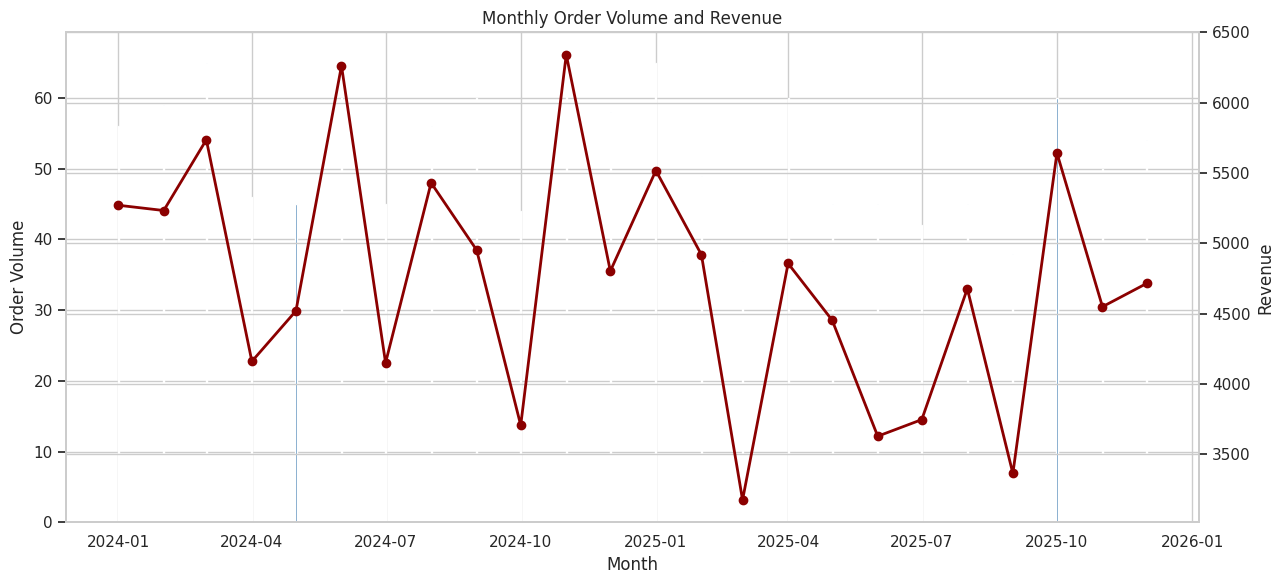

,month,order_volume,revenue
0,2024-01-01,56,5271.10
1,2024-02-01,59,5233.45
2,2024-03-01,65,5736.60
3,2024-04-01,46,4160.61
4,2024-05-01,45,4519.73
5,2024-06-01,60,6263.03
6,2024-07-01,45,4150.40
7,2024-08-01,56,5430.38
8,2024-09-01,60,4952.24
9,2024-10-01,44,3706.25


In [52]:
if "order_created_at" in full.columns:
    monthly = full.dropna(subset=["order_created_at"]).copy()
    monthly["month"] = monthly["order_created_at"].dt.to_period("M").dt.to_timestamp()

    trend = monthly.groupby("month").agg(
        order_volume=("order_id", "count"),
        revenue=("order_value", "sum")
    ).reset_index()

    fig, ax1 = plt.subplots(figsize=(13, 6))
    ax1.bar(trend["month"], trend["order_volume"], color="steelblue", label="Order Volume")
    ax1.set_ylabel("Order Volume")
    ax1.set_xlabel("Month")

    ax2 = ax1.twinx()
    ax2.plot(trend["month"], trend["revenue"], color="darkred", marker="o", linewidth=2, label="Revenue")
    ax2.set_ylabel("Revenue")

    plt.title("Monthly Order Volume and Revenue")
    fig.tight_layout()
    plt.savefig("northstar_monthly_trend.png", dpi=300)
    plt.show()

    display(trend)

,customer_id,complaint_count
124,C0368,4
86,C0242,3
70,C0191,3
58,C0172,3
101,C0282,3
46,C0142,3
142,C0421,3
127,C0372,3
37,C0110,3
189,C0545,3


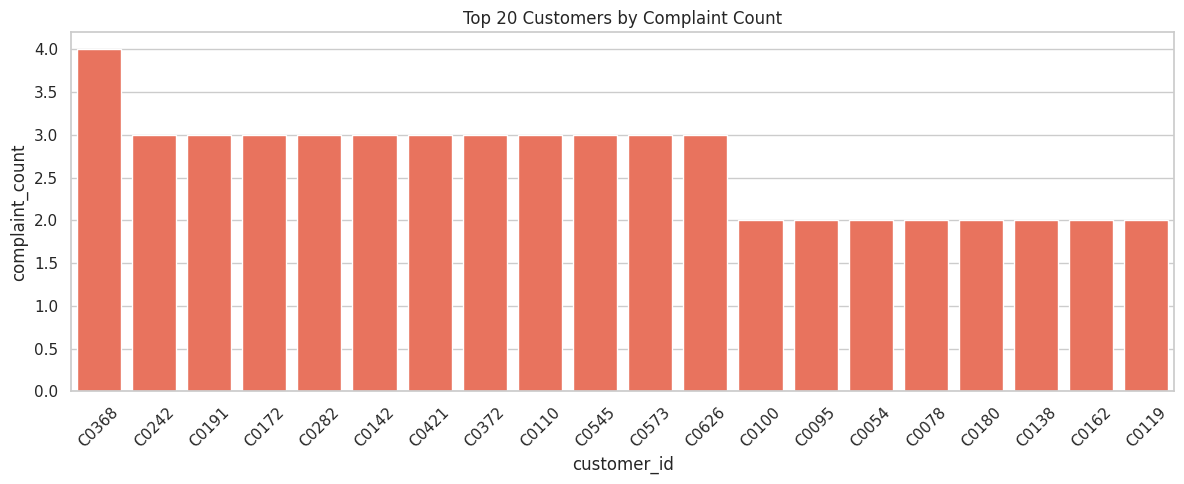

In [53]:
if "customer_id" in complaints.columns:
    complaint_counts = complaints.groupby("customer_id").size().reset_index(name="complaint_count")
    top_complainers = complaint_counts.sort_values("complaint_count", ascending=False).head(20)
    display(top_complainers)

    plt.figure(figsize=(12, 5))
    sns.barplot(data=top_complainers, x="customer_id", y="complaint_count", color="tomato")
    plt.title("Top 20 Customers by Complaint Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("northstar_top_complainers.png", dpi=300)
    plt.show()

In [54]:
driver_cols = [c for c in ["driver_id", "training_score", "driver_rating", "years_experience", "employment_type"] if c in full.columns]
driver_stats = full[driver_cols].drop_duplicates()

if "driver_id" in deliveries.columns:
    driver_deliveries = deliveries.groupby("driver_id").agg(
        total_deliveries=("delivery_id", "count"),
        failed_deliveries=("delivery_status", lambda x: x.astype(str).str.lower().isin(["failed"]).sum()),
        late_deliveries=("delivery_status", lambda x: x.astype(str).str.lower().isin(["delayed"]).sum())
    ).reset_index()

    driver_summary = drivers.merge(driver_deliveries, on="driver_id", how="left")
    display(driver_summary.head())

,driver_id,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag,total_deliveries,failed_deliveries,late_deliveries
0,D001,AIRPORT,FullTime,8,67.8,3.54,Morning,1,6,1,1
1,D002,Central,FullTime,4,42.4,3.94,Evening,1,7,1,2
2,D003,AIRPORT,FullTime,11,96.5,5.00,Evening,1,4,0,1
3,D004,Airport,PartTime,13,88.9,4.75,Morning,1,9,3,1
4,D005,north,FullTime,3,69.7,4.14,Morning,1,5,2,1


,hub_id,total_orders,avg_order_value,avg_delay_hours,avg_rating
4,H05,115,99.757739,3.303300,3.659913
5,H06,104,86.326827,2.801634,3.886394
7,H08,128,88.723906,2.713033,3.886094
3,H04,127,90.064409,2.240566,3.909843
0,H01,136,91.753309,2.235816,3.844154
1,H02,106,90.354811,2.056268,3.954481
6,H07,115,89.932435,1.674777,3.889565
2,H03,119,97.684958,1.587425,3.887773


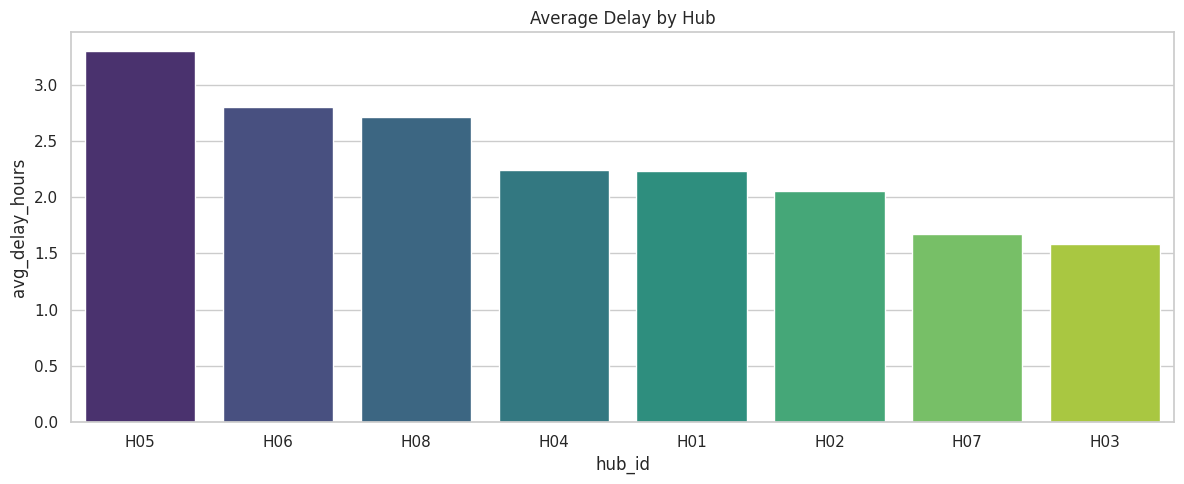

In [55]:
if "hub_id" in full.columns:
    hub_summary = full.groupby("hub_id").agg(
        total_orders=("order_id", "count"),
        avg_order_value=("order_value", "mean"),
        avg_delay_hours=("delay_hours", "mean"),
        avg_rating=("customer_rating_post_delivery", "mean")
    ).reset_index()

    display(hub_summary.sort_values("avg_delay_hours", ascending=False))

    plt.figure(figsize=(12, 5))
    sns.barplot(data=hub_summary.sort_values("avg_delay_hours", ascending=False), x="hub_id", y="avg_delay_hours", palette="viridis")
    plt.title("Average Delay by Hub")
    plt.tight_layout()
    plt.savefig("northstar_hub_delay.png", dpi=300)
    plt.show()

In [56]:
full.to_csv("northstar_cleaned_master.csv", index=False)
summary.to_csv("northstar_summary_metrics.csv", index=False)

print("Cleaned datasets saved")

Cleaned datasets saved


In [57]:
print(full.shape)
display(full.head())

(1250, 48)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag,delivery_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version,hub_name,zone,hub_type,capacity_score,delivery_duration_hours,delay_hours,is_late,is_failed,is_override,proof_missing,service_quality_issue
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0,DL00937,D047,V090,H01,2024-08-20 16:29:00,2024-08-20 18:52:56.172161,OnTime,26.65,2.0,0.0,4.29,15.82,South,FullTime,7.0,64.6,4.70,Morning,1.0,Hybrid,West,2024-08-16 01:10:00,93.8,98472.0,InRepair,v2.0,North Exchange,North,Dispatch,82.0,2.398937,-3.601063,0,0,1,0,1
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,Nan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nan,NaT,NaN,NaN,NaN,NaN,NaN,Nan,NaN,NaN,NaN,NaN,0,0,0,0,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,0,DL00925,D041,V100,H02,2025-09-02 16:59:00,2025-09-03 01:50:39.644673,Delayed,13.04,2.0,0.0,3.70,13.16,East,PartTime,3.0,88.2,3.67,Morning,1.0,CargoVan,East,2024-06-23 11:24:00,60.1,31876.0,Active,v2.0,South Link,South,Dispatch,78.0,8.861012,4.861012,1,0,1,0,1
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,1,DL00002,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1.0,0.0,5.00,13.41,Ctr,PartTime,11.0,69.2,4.61,Evening,1.0,Diesel,Airport,2025-09-17 08:52:00,68.6,78468.0,Active,v2.2,South Link,South,Dispatch,78.0,NaN,NaN,0,0,1,0,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,0,DL00671,D054,V073,H03,2025-02-17 20:23:00,2025-02-18 08:05:00.047082,OnTime,16.01,1.0,0.0,4.38,13.53,West,FullTime,3.0,80.1,4.32,Morning,1.0,Hybrid,Airport,2024-05-28 05:33:00,NaN,191353.0,Active,v2.1,East Dock,East,Warehouse,74.0,11.700013,-0.299987,0,0,1,0,1


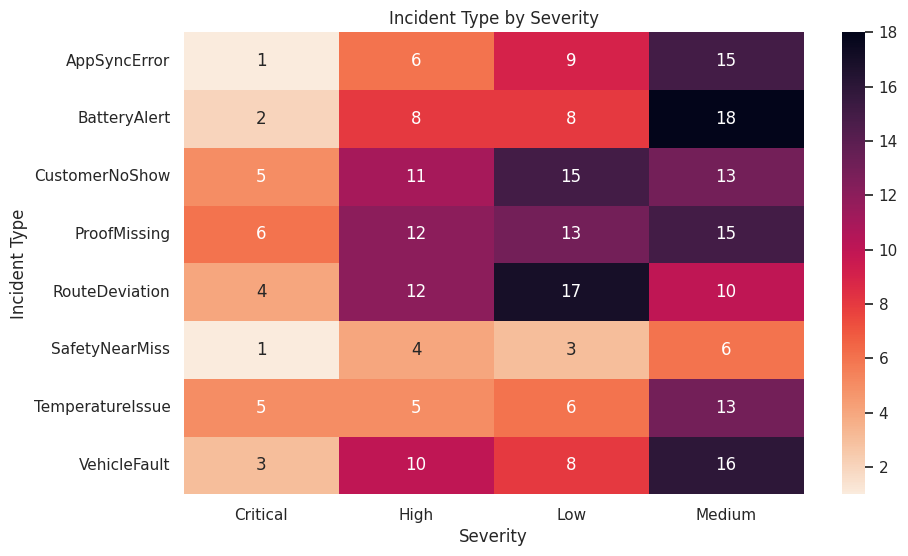

In [58]:
incident_heat = incidents.pivot_table(
    index="incident_type",
    columns="severity",
    values="incident_id",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(10,6))
sns.heatmap(incident_heat, annot=True, cmap="rocket_r", fmt="g")
plt.title("Incident Type by Severity")
plt.xlabel("Severity")
plt.ylabel("Incident Type")
plt.show()

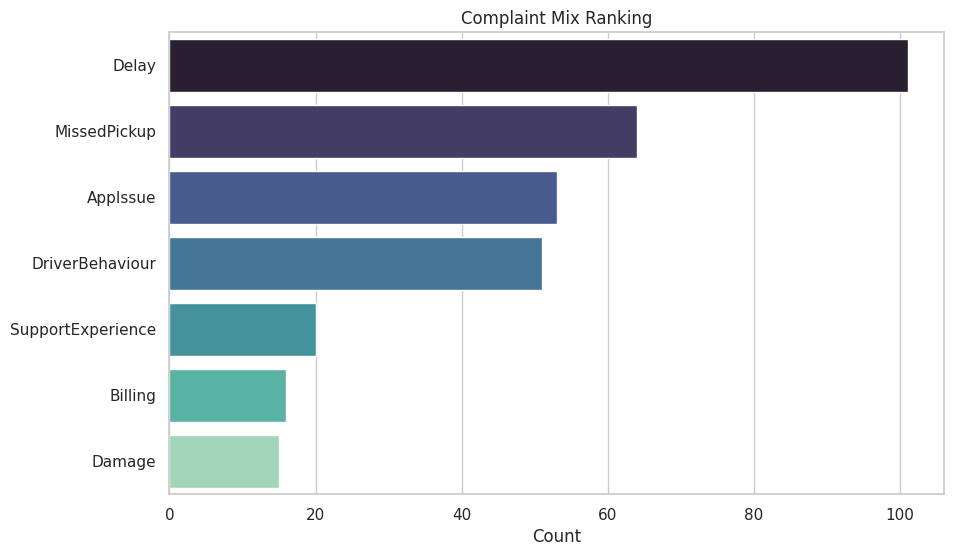

In [59]:
complaint_mix = complaints["complaint_type"].value_counts().reset_index()
complaint_mix.columns = ["complaint_type","count"]

plt.figure(figsize=(10,6))
sns.barplot(data=complaint_mix, x="count", y="complaint_type", palette="mako")
plt.title("Complaint Mix Ranking")
plt.xlabel("Count")
plt.ylabel("")
plt.show()